# IMPORT

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# LOAD DATA

In [2]:
X = np.load("saved/X.npy", allow_pickle=True)
Y = np.load("saved/Y_encoded.npy", allow_pickle=True)
groups = np.load("saved/groups.npy", allow_pickle=True)

print(X.shape, Y.shape)

(3953, 86) (3953, 90)


# LABEL ANALYSIS

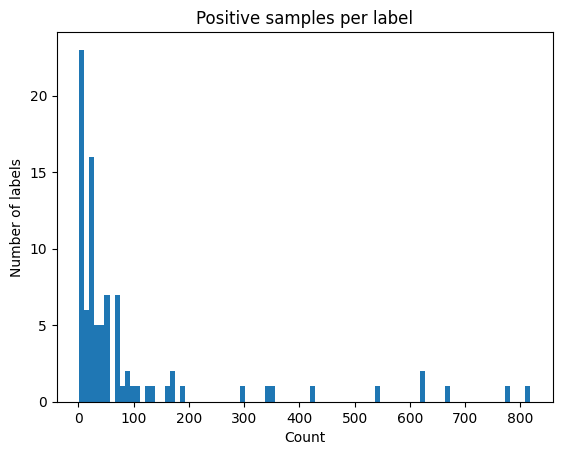

In [ ]:
label_counts = Y.sum(axis=0)

plt.hist(label_counts, bins=len(label_counts))
plt.title("Positive samples per label")
plt.xlabel("Count")
plt.ylabel("Number of labels")
plt.show()

# Here we can see that a few classes are much more common than others, and there are several rare classes with very few samples. This imbalance can make it difficult for models to learn to predict the rare classes effectively, and may require techniques such as class weighting, oversampling, or undersampling to address.

# LABELS WITH ONLY ONE CLASS

In [6]:
single_class = [i for i in range(Y.shape[1]) if len(np.unique(Y[:, i])) == 1]
print(f"{len(single_class)} / {Y.shape[1]} labels have only one class")

0 / 90 labels have only one class


# FEATURE ANALYSIS

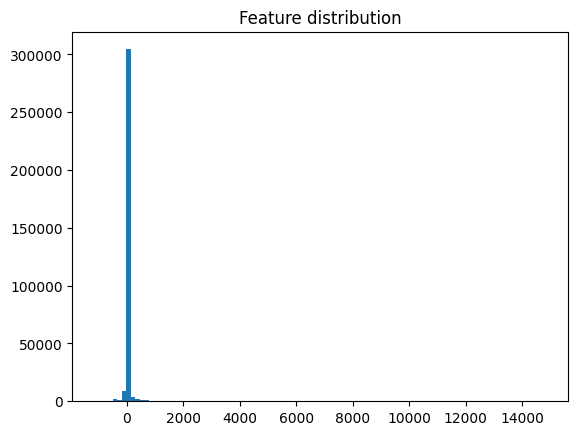

In [ ]:
plt.hist(X.flatten(), bins=100)
plt.title("Feature distribution")
plt.show()

# This justifies that the importance of using StandardScaler. If there is a big difference between min and max, without scaling the models will be incorrect.

# FEATURE VARIANCE

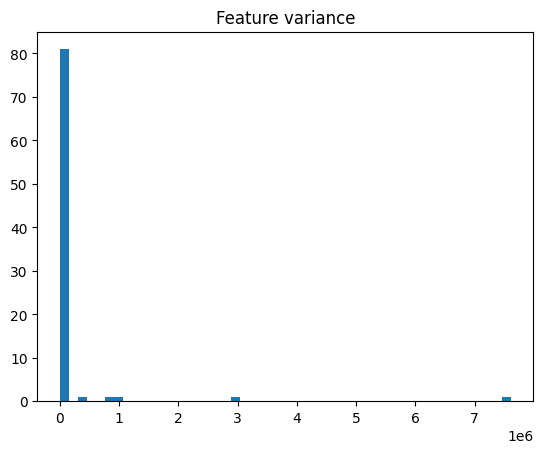

In [10]:
variances = np.var(X, axis=0)

plt.hist(variances, bins=50)
plt.title("Feature variance")
plt.show()

# DIMENSIONALITY REDUCTION (PCA)

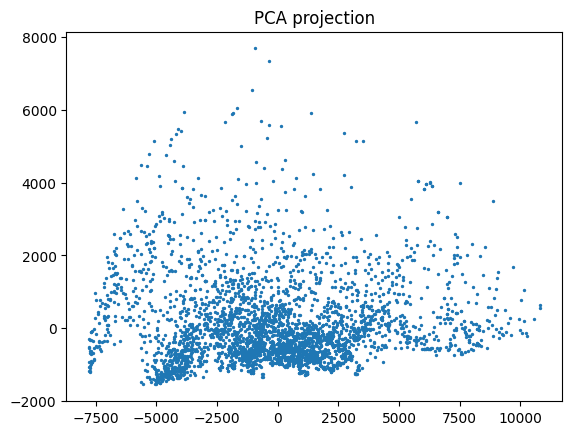

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], s=2)
plt.title("PCA projection")
plt.show()

# PCA WITH LABELS

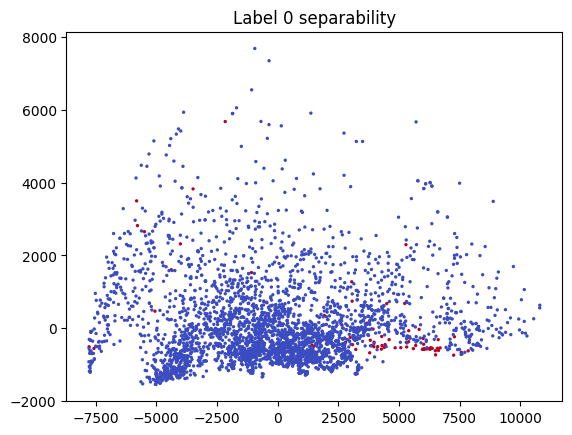

In [13]:
label_idx = 0

plt.scatter(X_pca[:,0], X_pca[:,1],
            c=Y[:, label_idx], cmap="coolwarm", s=2)
plt.title(f"Label {label_idx} separability")
plt.show()

# We can see that there is not much of the second pca. This means that because of the imbalance of the data, linear regression will predict the majority class and "succeed", when in reality it will not. 

# GROUP ANALYSIS

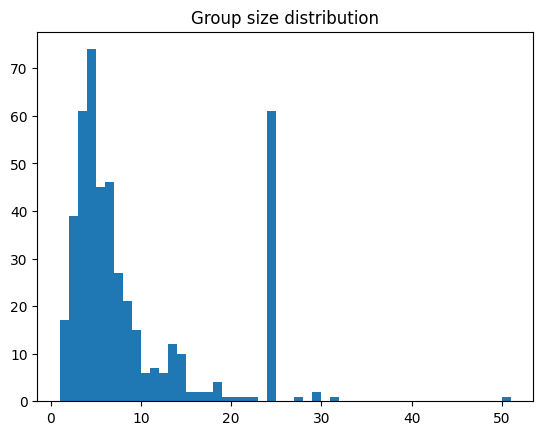

In [14]:
unique, counts = np.unique(groups, return_counts=True)

plt.hist(counts, bins=50)
plt.title("Group size distribution")
plt.show()